## m8 — Relabeled Coordinate Origin Experiments

Same GazeNetM5 architecture and training setup as m5c, run three times
on different label sets generated by shifting the PoG coordinate origin:

| Variant | Shift | Rationale |
|---------|-------|-----------|
| **Naive** | (0.37, -1.36) | Data centroid — average across all devices/orientations |
| **Balanced** | (-0.30, -3.60) | Optimized for 4-class balance (1.70x max/min ratio) |
| **Aggressive** | (0.66, -5.92) | iPhone portrait screen center — matches deployment target |

**Only change from m5c:** the label CSV. Architecture, transforms, geo features,
and training hyperparameters are identical. Class weights are recomputed
dynamically from each label set's training split distribution.

## Setup

In [1]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.4 MB/s eta 0:00:00


In [2]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# IMPORT TORCH
# ============================================================
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# ============================================================
# EXPERIMENT CONFIG
# ============================================================

EXPERIMENTS = {
    'naive': {
        'label_csv': '/content/drive/MyDrive/210/gaze_labels_naive.csv',
        'shift': (0.37, -1.36),
    },
    'balanced': {
        'label_csv': '/content/drive/MyDrive/210/gaze_labels_balanced.csv',
        'shift': (-0.30, -3.60),
    },
    'aggressive': {
        'label_csv': '/content/drive/MyDrive/210/gaze_labels_aggressive.csv',
        'shift': (0.66, -5.92),
    },
}

# Shared paths
TAR_DIR         = "/content/gaze_wds_balanced"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"
CHECKPOINT_DIR  = "/content/drive/MyDrive/210"

# Verify label CSVs exist
for name, cfg in EXPERIMENTS.items():
    exists = os.path.exists(cfg['label_csv'])
    print(f"  {name:12s}: {cfg['label_csv']} — {'OK' if exists else 'MISSING'}")

  naive       : /content/drive/MyDrive/210/gaze_labels_naive.csv — OK
  balanced    : /content/drive/MyDrive/210/gaze_labels_balanced.csv — OK
  aggressive  : /content/drive/MyDrive/210/gaze_labels_aggressive.csv — OK


## Load data to disk

In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK (once, shared across experiments)
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# ============================================================
# VERIFY TAR FILES
# ============================================================

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Train tars: 75
Val tars:   16
Test tars:  16
Geo parquet: True


In [8]:
# ============================================================
# LOAD GEO FEATURES (once, shared across experiments)
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# Neutral default for missing samples
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


## Shared definitions

In [9]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

# Training (with augmentation)
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Val/Test (clean)
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [10]:
# ============================================================
# GazeNetM5 — Model Definition (identical to m5c)
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # Eye CNN (shared weights for left and right)
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Face CNN
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Geometric feature branch
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # FC classifier
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"  Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
  Parameters: 6,586,820


In [11]:
# ============================================================
# make_dataset_4class — uses global current_label_lookup_4
# (global instead of parameter so WebDataset workers can access it)
# ============================================================

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}
current_label_lookup_4 = {}  # set per experiment before building loaders

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = current_label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


In [16]:
# ============================================================
# Training + evaluation function
# Encapsulates the full m5c pipeline for one label set
# ============================================================

label_names = ['Up', 'Down', 'Left', 'Right']
label_names_map = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
teal_cmap = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])


def run_experiment(exp_name, label_csv, checkpoint_path):
    """
    Full train + eval pipeline for one label variant.
    Returns a dict with metrics for comparison.
    """
    global current_label_lookup_4

    print(f"\n{'#'*60}")
    print(f"# EXPERIMENT: {exp_name}")
    print(f"# Labels: {label_csv}")
    print(f"# Checkpoint: {checkpoint_path}")
    print(f"{'#'*60}")

    # ---- Load labels ----
    df_labels = pd.read_csv(label_csv, dtype={'subject_id': str})
    print(f"\nLoaded {len(df_labels)} labeled frames")

    label_lookup = {}
    for _, row in df_labels.iterrows():
        key = f"{int(row['subject_id']):05d}_{int(row['frame_idx']):06d}"
        label_lookup[key] = row['label']

    # Filter to 4 classes (drop Straight)
    label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}
    print(f"4-class samples: {len(label_lookup_4)} (dropped {len(label_lookup) - len(label_lookup_4)} Straight)")

    # ---- Set global for WebDataset workers ----
    current_label_lookup_4 = label_lookup_4

    # ---- Build data loaders ----
    train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
    val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
    test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

    train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
    val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
    test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

    # ---- Compute class weights dynamically ----
    four_class_labels = [v for v in label_lookup_4.values()]
    train_counts = [four_class_labels.count(c) for c in label_names]  # Up, Down, Left, Right
    total = sum(train_counts)
    n_classes = 4
    weights = [math.sqrt(total / (n_classes * c)) for c in train_counts]
    weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

    print(f"\nClass distribution (4-class):")
    for name, ct, w in zip(label_names, train_counts, weights):
        print(f"  {name:6s}: {ct:>7,} ({ct/total*100:.1f}%)  weight={w:.3f}")

    # ---- Model, loss, optimizer ----
    model = GazeNetM5(num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3)

    # ---- Training loop (identical to m5c) ----
    num_epochs = 20
    best_val_loss = float('inf')
    patience = 6
    patience_counter = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"\n{'='*50}")
        print(f"[{exp_name}] Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*50}")

        # ---- Train ----
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        epoch_start = time.time()

        for batch_idx, batch in enumerate(train_loader):
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            if (batch_idx + 1) % 1000 == 0:
                elapsed = time.time() - epoch_start
                batches_done = batch_idx + 1
                eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
                print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

        # Safety check: if no batches ran, something is wrong
        if train_total == 0:
            raise RuntimeError(f"[{exp_name}] Train loader yielded 0 samples — check label key format")

        avg_train_loss = train_loss / (batch_idx + 1)
        train_acc = 100 * train_correct / train_total
        epoch_time = time.time() - epoch_start

        # ---- Validate ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                val_batch_count += 1
                left_eye     = batch['left_eye'].to(device)
                right_eye    = batch['right_eye'].to(device)
                face         = batch['face'].to(device)
                geo_features = batch['geo_features'].to(device)
                labels       = batch['label'].to(device)

                outputs = model(left_eye, right_eye, face, geo_features)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / val_batch_count
        val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        scheduler.step(avg_val_loss)

        print(f"\n  Time: {epoch_time/60:.1f} min")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Gap: {train_acc - val_acc:.2f}%")

        # ---- Checkpoint ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{patience})")

        # ---- Early stopping ----
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    print(f"\n[{exp_name}] Training complete! Best val loss: {best_val_loss:.4f}")

    # ---- Per-experiment training curves (loss, accuracy, gap) ----
    teal_dark  = '#0D7377'
    teal_light = '#45C4B0'
    teal_mid   = '#14A3A8'

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    ep_range = range(1, len(train_losses) + 1)

    axes[0].plot(ep_range, train_losses, '-o', color=teal_dark, label='Train', markersize=5)
    axes[0].plot(ep_range, val_losses, '-o', color=teal_light, label='Val', markersize=5)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss', fontweight='bold', color=teal_dark)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep_range, train_accuracies, '-o', color=teal_dark, label='Train', markersize=5)
    axes[1].plot(ep_range, val_accuracies, '-o', color=teal_light, label='Val', markersize=5)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy', fontweight='bold', color=teal_dark)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
    axes[2].plot(ep_range, gap, '-o', color=teal_mid, markersize=5)
    axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy Gap (%)')
    axes[2].set_title('Train-Val Gap', fontweight='bold', color=teal_dark)
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'm8_{exp_name} — Training Curves',
                 fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
    plt.tight_layout()
    plt.show()

    # ---- Test evaluation ----
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels_batch = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    # ---- Confusion matrix ----
    cm = confusion_matrix(all_labels, all_preds)
    test_acc = 100 * np.sum(np.diag(cm)) / np.sum(cm)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, linecolor='white')
    plt.xlabel('Predicted', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.title(f'm8_{exp_name} Confusion Matrix (Test) — acc={test_acc:.1f}%',
              fontweight='bold', color='#0D7377', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"m8_{exp_name} Test Set Performance")
    print(f"{'='*50}")
    report_str = classification_report(all_labels, all_preds, target_names=label_names)
    print(report_str)

    # ---- Collect metrics for comparison ----
    p, r, f1, s = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])

    return {
        'name': exp_name,
        'test_acc': test_acc,
        'precision': dict(zip(label_names, p)),
        'recall': dict(zip(label_names, r)),
        'f1': dict(zip(label_names, f1)),
        'support': dict(zip(label_names, s)),
        'confusion_matrix': cm,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'class_weights': weights,
        'train_counts': train_counts,
    }

print("run_experiment() defined")

run_experiment() defined


## Run all experiments


############################################################
# EXPERIMENT: naive
# Labels: /content/drive/MyDrive/210/gaze_labels_naive.csv
# Checkpoint: /content/drive/MyDrive/210/m8_naive.pth
############################################################

Loaded 849131 labeled frames
4-class samples: 594143 (dropped 254988 Straight)

Class distribution (4-class):
  Up    :  31,564 (5.3%)  weight=2.169
  Down  : 183,016 (30.8%)  weight=0.901
  Left  : 208,435 (35.1%)  weight=0.844
  Right : 171,128 (28.8%)  weight=0.932

[naive] Epoch 1/20
  Batch 1000/~7000 - Loss: 1.0797 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.5980 - ETA: 10.9 min
  Batch 3000/~7000 - Loss: 0.5975 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.7489 - ETA: 6.2 min

  Time: 9.1 min
  Train Loss: 0.7858 | Train Acc: 84.22%
  Val Loss:   0.6660 | Val Acc:   89.86%
  Gap: -5.65%
  Saved best model (val_loss=0.6660)

[naive] Epoch 2/20
  Batch 1000/~7000 - Loss: 0.4922 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.7915 - 

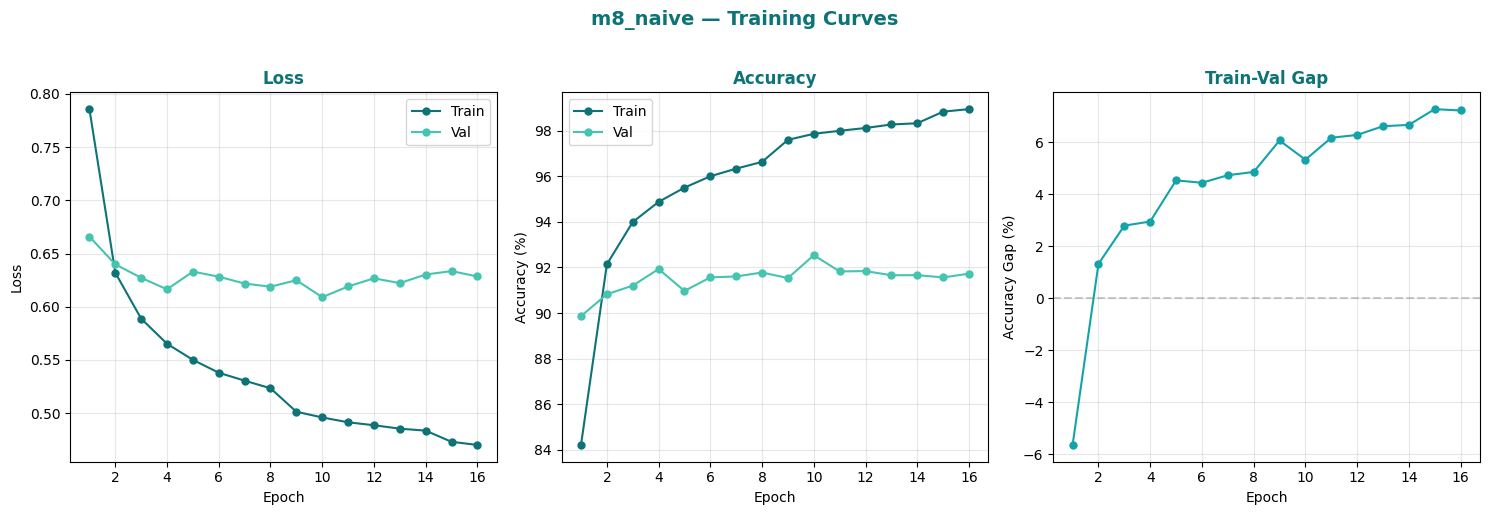

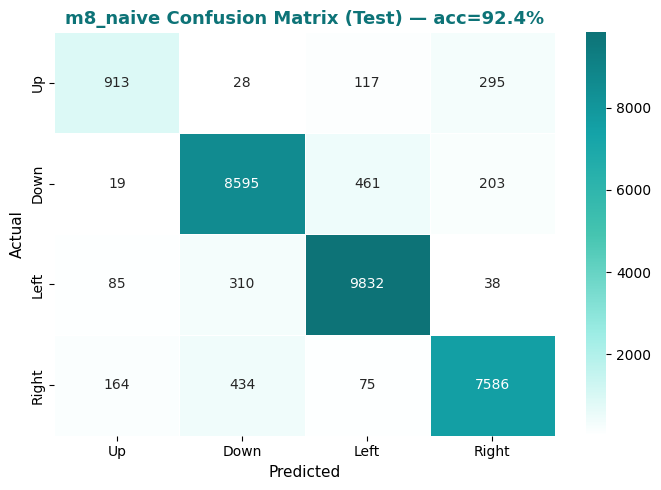


m8_naive Test Set Performance
              precision    recall  f1-score   support

          Up       0.77      0.67      0.72      1353
        Down       0.92      0.93      0.92      9278
        Left       0.94      0.96      0.95     10265
       Right       0.93      0.92      0.93      8259

    accuracy                           0.92     29155
   macro avg       0.89      0.87      0.88     29155
weighted avg       0.92      0.92      0.92     29155


############################################################
# EXPERIMENT: balanced
# Labels: /content/drive/MyDrive/210/gaze_labels_balanced.csv
# Checkpoint: /content/drive/MyDrive/210/m8_balanced.pth
############################################################

Loaded 849131 labeled frames
4-class samples: 561138 (dropped 287993 Straight)

Class distribution (4-class):
  Up    : 111,441 (19.9%)  weight=1.122
  Down  : 102,624 (18.3%)  weight=1.169
  Left  : 172,884 (30.8%)  weight=0.901
  Right : 174,189 (31.0%)  weight=0.89

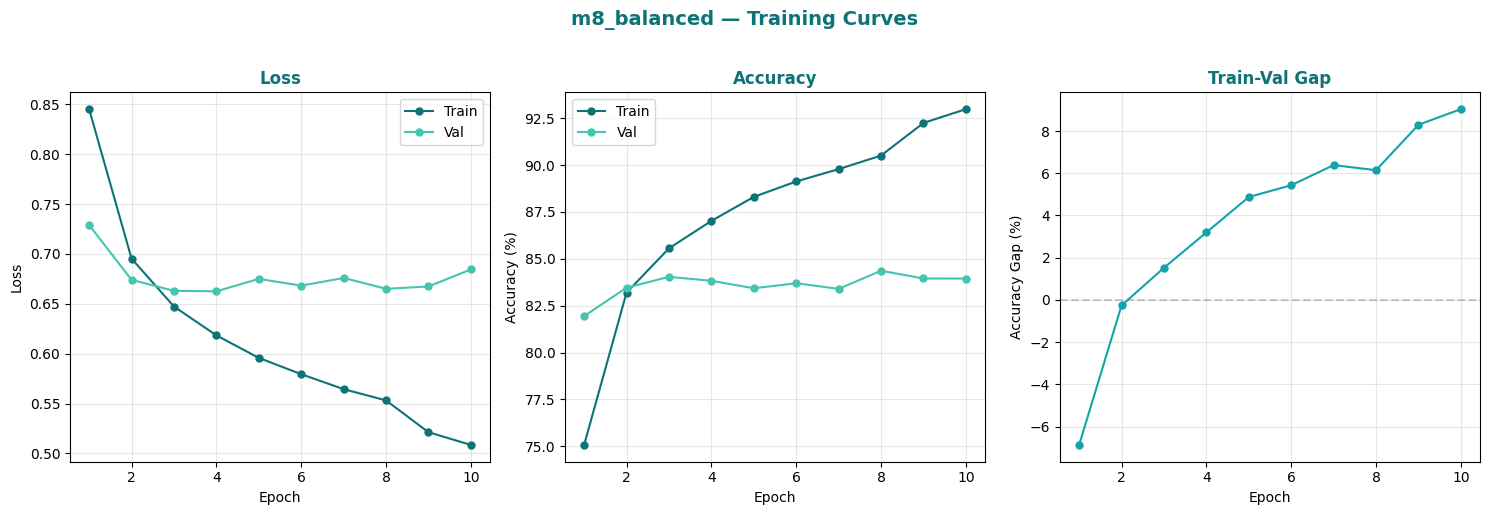

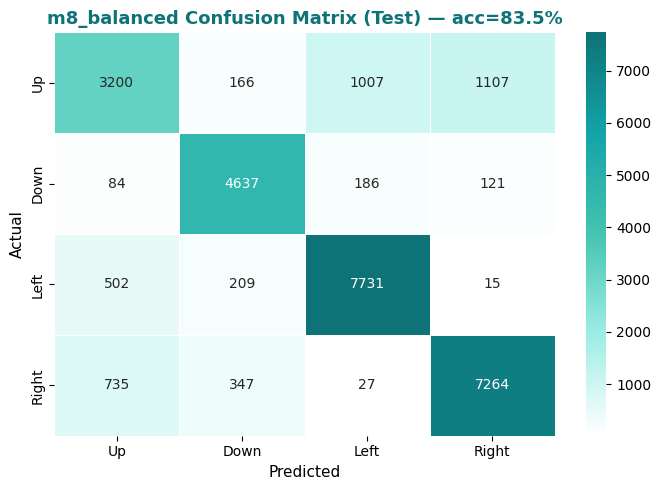


m8_balanced Test Set Performance
              precision    recall  f1-score   support

          Up       0.71      0.58      0.64      5480
        Down       0.87      0.92      0.89      5028
        Left       0.86      0.91      0.89      8457
       Right       0.85      0.87      0.86      8373

    accuracy                           0.84     27338
   macro avg       0.82      0.82      0.82     27338
weighted avg       0.83      0.84      0.83     27338


############################################################
# EXPERIMENT: aggressive
# Labels: /content/drive/MyDrive/210/gaze_labels_aggressive.csv
# Checkpoint: /content/drive/MyDrive/210/m8_aggressive.pth
############################################################

Loaded 849131 labeled frames
4-class samples: 607431 (dropped 241700 Straight)

Class distribution (4-class):
  Up    : 294,748 (48.5%)  weight=0.718
  Down  :  39,493 (6.5%)  weight=1.961
  Left  : 168,186 (27.7%)  weight=0.950
  Right : 105,004 (17.3%)  wei

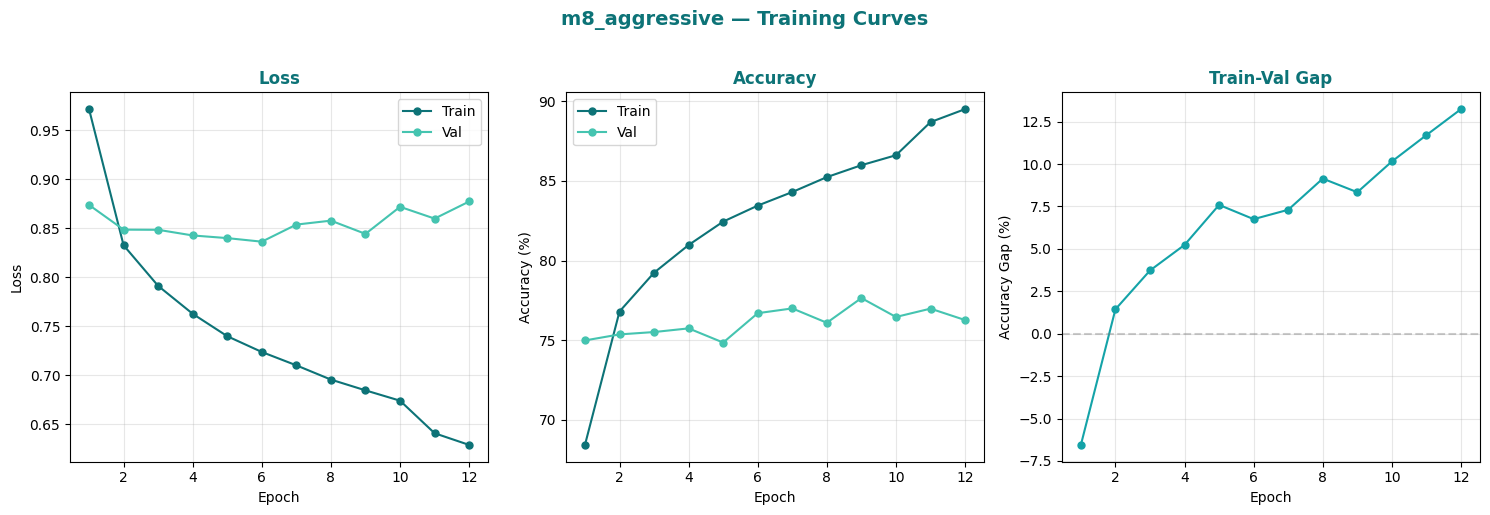

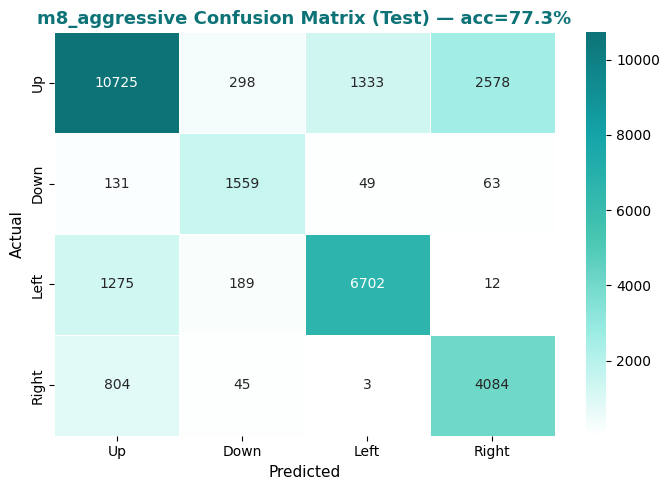


m8_aggressive Test Set Performance
              precision    recall  f1-score   support

          Up       0.83      0.72      0.77     14934
        Down       0.75      0.87      0.80      1802
        Left       0.83      0.82      0.82      8178
       Right       0.61      0.83      0.70      4936

    accuracy                           0.77     29850
   macro avg       0.75      0.81      0.77     29850
weighted avg       0.79      0.77      0.77     29850


ALL EXPERIMENTS COMPLETE
  m8_naive: test acc = 92.4%
  m8_balanced: test acc = 83.5%
  m8_aggressive: test acc = 77.3%


In [17]:
# ============================================================
# RUN ALL THREE EXPERIMENTS SEQUENTIALLY
# ============================================================

all_results = {}

for exp_name, cfg in EXPERIMENTS.items():
    checkpoint = f"{CHECKPOINT_DIR}/m8_{exp_name}.pth"
    result = run_experiment(exp_name, cfg['label_csv'], checkpoint)
    all_results[exp_name] = result

print(f"\n{'='*60}")
print(f"ALL EXPERIMENTS COMPLETE")
print(f"{'='*60}")
for name, res in all_results.items():
    print(f"  m8_{name}: test acc = {res['test_acc']:.1f}%")

## Compare results

In [18]:
# ============================================================
# COMPARISON: m5c (original) vs m8 variants
# ============================================================

# !!! Hardcoded m5c results for reference
m5c_metrics = {
    'name': 'm5c (original)',
    'test_acc': 92.0,
    'f1': {'Up': 0.74, 'Down': 0.93, 'Left': 0.93, 'Right': 0.93},
    'recall': {'Up': 0.73, 'Down': 0.93, 'Left': 0.94, 'Right': 0.92},
    'precision': {'Up': 0.76, 'Down': 0.93, 'Left': 0.93, 'Right': 0.93},
}

# Build comparison including m5c
all_for_comparison = {'m5c': m5c_metrics}
all_for_comparison.update(all_results)

# ---- Summary table ----
print(f"{'Experiment':<20s} {'Acc':>6s}  {'Up F1':>6s} {'Dn F1':>6s} {'L F1':>6s} {'R F1':>6s}")
print("-" * 60)
for key, res in all_for_comparison.items():
    display_name = res.get('name', key)
    print(f"{display_name:<20s} {res['test_acc']:>5.1f}%  "
          f"{res['f1']['Up']:>6.3f} {res['f1']['Down']:>6.3f} "
          f"{res['f1']['Left']:>6.3f} {res['f1']['Right']:>6.3f}")

Experiment              Acc   Up F1  Dn F1   L F1   R F1
------------------------------------------------------------
m5c (original)        92.0%   0.740  0.930  0.930  0.930
naive                 92.4%   0.721  0.922  0.948  0.926
balanced              83.5%   0.640  0.893  0.888  0.861
aggressive            77.3%   0.770  0.801  0.824  0.700


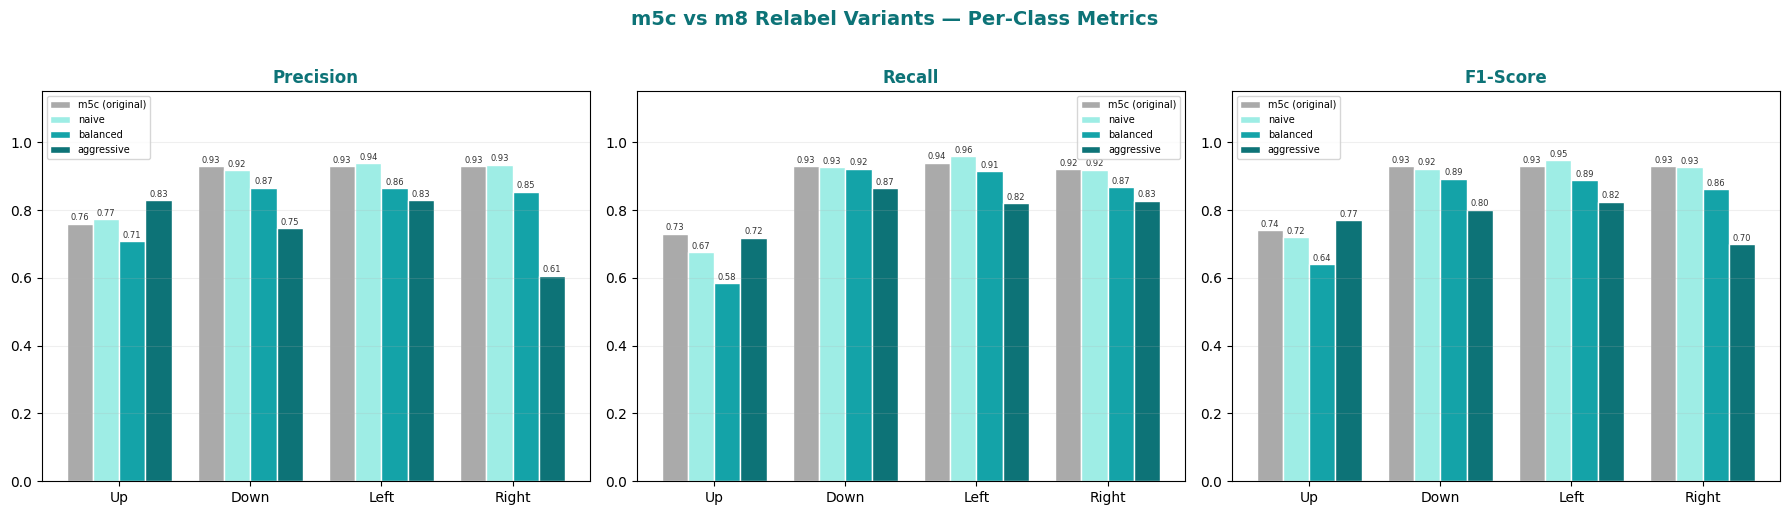

In [19]:
# ============================================================
# COMPARISON BAR CHARTS: F1 per class across all experiments
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'
teal_pale  = '#9EEDE5'

exp_colors = {
    'm5c': '#AAAAAA',
    'naive': teal_pale,
    'balanced': teal_mid,
    'aggressive': teal_dark,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(4)
n_bars = len(all_for_comparison)
width = 0.8 / n_bars

for ax, metric, title in [
    (axes[0], 'precision', 'Precision'),
    (axes[1], 'recall', 'Recall'),
    (axes[2], 'f1', 'F1-Score'),
]:
    for i, (key, res) in enumerate(all_for_comparison.items()):
        vals = [res[metric][c] for c in label_names]
        color = exp_colors.get(key, '#888888')
        display_name = res.get('name', key)
        bars = ax.bar(x + i * width - (n_bars - 1) * width / 2, vals,
                      width, label=display_name, color=color, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', fontsize=6, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontweight='bold', color=teal_dark)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('m5c vs m8 Relabel Variants — Per-Class Metrics',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

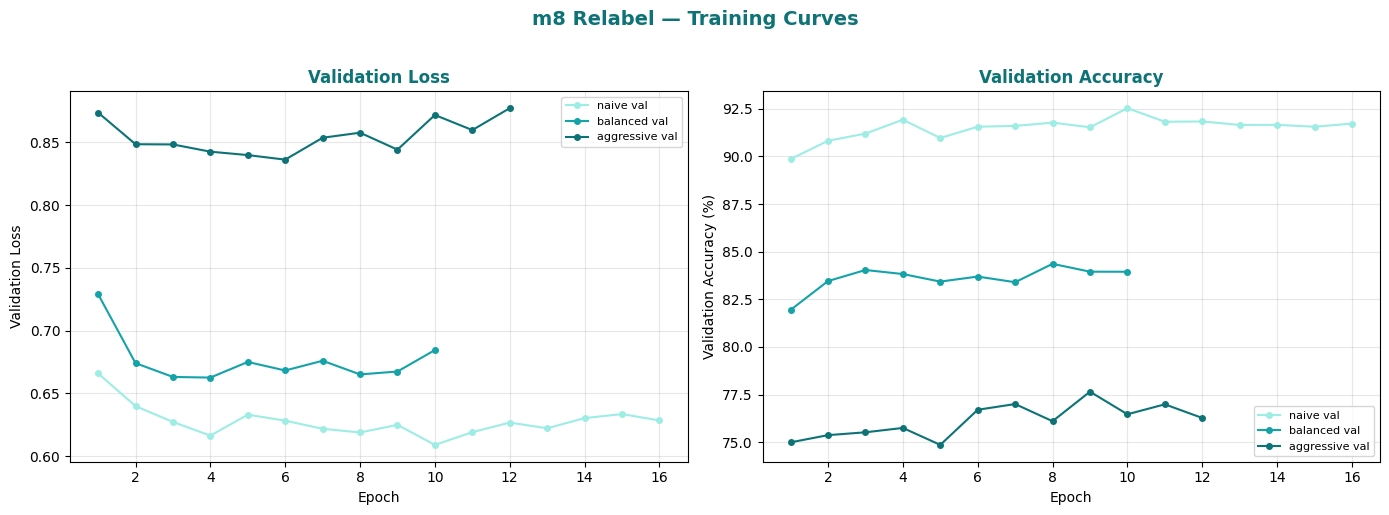

In [20]:
# ============================================================
# TRAINING CURVES — all three experiments
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

curve_colors = {'naive': teal_pale, 'balanced': teal_mid, 'aggressive': teal_dark}

for exp_name, res in all_results.items():
    c = curve_colors[exp_name]
    epochs = range(1, len(res['val_losses']) + 1)

    axes[0].plot(epochs, res['val_losses'], '-o', color=c, markersize=4, label=f'{exp_name} val')
    axes[1].plot(epochs, res['val_accuracies'], '-o', color=c, markersize=4, label=f'{exp_name} val')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss', fontweight='bold', color=teal_dark)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Validation Accuracy', fontweight='bold', color=teal_dark)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('m8 Relabel — Training Curves', fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# SAVE RAW RESULTS
# ============================================================

for exp_name, res in all_results.items():
    print(f"\n--- m8_{exp_name} ---")
    print(f"train_losses = {res['train_losses']}")
    print(f"val_losses = {res['val_losses']}")
    print(f"train_acc = {res['train_accuracies']}")
    print(f"val_acc = {res['val_accuracies']}")
    print(f"class_weights = {res['class_weights']}")
    print(f"train_counts = {res['train_counts']}")
    ckpt = f"{CHECKPOINT_DIR}/m8_{exp_name}.pth"
    print(f"Checkpoint: {os.path.exists(ckpt)}, {os.path.getsize(ckpt)/1e6:.1f} MB")


--- m8_naive ---
train_losses = [0.7857544779958273, 0.6320007717398071, 0.588806170029103, 0.5652319376900226, 0.5500958606944875, 0.5379832341783887, 0.5305454767484444, 0.5233797428280929, 0.5013322761099406, 0.495962905013425, 0.49140724884565545, 0.4886440898200307, 0.4854046534360192, 0.483578400843233, 0.47304673314595075, 0.47013077447123536]
val_losses = [0.6659671469536392, 0.6398390011124218, 0.6272373206212546, 0.6163644311943121, 0.6330394921229414, 0.6282661742899615, 0.6217968882895513, 0.6188521146358928, 0.6249336708644264, 0.6089764898177777, 0.6191029658716315, 0.6267453990746874, 0.6221921295619869, 0.6303064198201819, 0.6335177212503591, 0.6284392155386707]
train_acc = [84.21658902182075, 92.13709236455895, 93.98817465351443, 94.873982050553, 95.49659893703112, 95.9960047534685, 96.33064310346084, 96.62591223580704, 97.59337430648206, 97.8565648170425, 97.98925366170177, 98.11173567215648, 98.26629630439696, 98.31951765417787, 98.82840124523378, 98.93921830231184]